## Recalculating BUI

* For BUI we take all the forces that are parallel to the coastline.
* The coastline angle ($\theta$) is then $112.27^{\circ}$ degrees for the Peruvian coastline
* After performing some geometry we:
    * Decompose the $\tau$ in X and Y coordinates
    * Decompose the $\tau^{y}$ and $\tau^{x}$ for the coastline

* Then we obtain:

  $\tau_{alongshore} = sin(\alpha) \cdot \tau^{y} + cos(\alpha) \cdot \tau^{x}$


* Then the relationship between $\alpha$ and $\theta$ is as follows:

  $\alpha = 180 - \theta $
  
* Finally the BUI is:

    $BUI = \dfrac{\tau_{\text{alongshore}}}{\rho\, f}$
 

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
from matplotlib.colors import TwoSlopeNorm 
import matplotlib.colors as mcolors

## Functions

In [2]:
##Normalize
def normalize(data):
    return (data - data.min()) / (data.max() - data.min())

## seasonality
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

def monthly_anomaly(da, dim=('lat','lon')):
    """
    Compute monthly climatological anomalies from a DataArray.
    
    Parameters:
    - da: xarray.DataArray with dimensions including 'time' and the spatial dim to average over
    - dim: spatial dimension to average over (e.g., 'lat')
    
    Returns:
    - anomaly: xarray.DataArray with monthly anomalies (same time dimension as input)
    """
    # Step 1: mean over the spatial dimension
    da_mean = da.mean(dim=dim, skipna=True)
    
    # Step 2: compute monthly climatology (climatological mean per month)
    monthly_clim = da_mean.groupby('time.month').mean(dim='time')
    
    # Step 3: subtract climatology to get anomaly
    anomaly = da_mean.groupby('time.month') - monthly_clim

    return anomaly

In [3]:
time = pd.date_range(start="1980-01",end="2016-01",freq='M')

ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})

/tmp/ipykernel_2383869/3366088229.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start="1980-01",end="2016-01",freq='M')


In [4]:
## kml to struct
def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [5]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

## Lon and lat for the whole dataset
lat = np.linspace(-33.0, 10.03286, 542).reshape(542, 1)  # Reshape to match eta_rho
lon = np.linspace(-118.9083, -68.90833, 602).reshape(1, 602)  # Reshape to match xi_rho

lats, lons = np.meshgrid(lat.flatten(), lon.flatten(), indexing="ij")

LON=lons
LAT=lats
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

## Data

In [6]:
#--- winds
new_w = loadmat("../../NHCS/Processed/new_winds.mat")

winds_ds = xr.Dataset(
    data_vars={
        'u10': (("time", "lat","lon"), new_w['uwind'].transpose(2, 1, 0)),
        'v10':(("time", "lat","lon"), new_w['vwind'].transpose(2, 1, 0))
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

winds_ds

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    u10      (time, lat, lon) float64 1GB 1.432 1.435 1.439 ... nan nan nan
    v10      (time, lat, lon) float64 1GB -0.9696 -0.999 -1.031 ... nan nan nan

In [7]:
ws = np.sqrt(winds_ds.u10**2 + winds_ds.v10**2)
omega = 7.29e-5
rho = 1000
f = 2 * omega * np.sin(np.radians(winds_ds.lat))
pa = 1.22
cd = 1.3e-3
taux = pa * cd * ws * winds_ds.u10
tauy = pa * cd * ws * winds_ds.v10


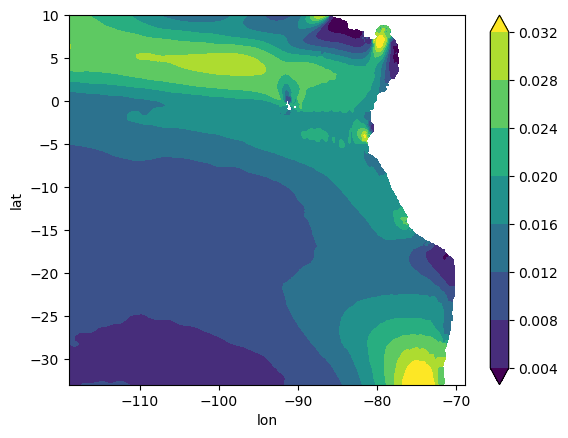

In [8]:
tauy.std('time').plot.contourf(robust=True)
# taux.std('time').plot(robust=True)

In [9]:
theta = 112.27
alpha = 180 - theta

tau_alongshore = np.sin(alpha) * tauy + np.cos(alpha) * taux
tau_alongshore

<xarray.DataArray (time: 432, lat: 542, lon: 602)> Size: 1GB
array([[[ 3.33811162e-03,  3.45787390e-03,  3.58971809e-03, ...,
                     nan,             nan,             nan],
        [ 3.41862389e-03,  3.54927487e-03,  3.69095218e-03, ...,
                     nan,             nan,             nan],
        [ 3.48628058e-03,  3.62864392e-03,  3.78002938e-03, ...,
                     nan,             nan,             nan],
        ...,
        [ 8.95591311e-03,  8.89249492e-03,  8.86822945e-03, ...,
                     nan,             nan,             nan],
        [ 9.12349121e-03,  9.06003792e-03,  9.03176294e-03, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[ 2.64984658e-03,  2.83517510e-03,  3.01350497e-03, ...,
                     nan,             nan,             nan],
        [ 2.69006438e-03,  2.86665399e-03,  3.03557742e-03, ...,
                     nan,             nan,             nan],
        [ 2.72136551e-03,  2.88690255e-03,  3.04407449e-03, ...,
                     nan,             nan,             nan],
...
        [-1.11668545e-04, -1.13716225e-04, -1.15181714e-04, ...,
                     nan,             nan,             nan],
        [-6.09153574e-05, -6.23769344e-05, -6.34889623e-05, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[-6.90069516e-04, -6.25864652e-04, -5.62009405e-04, ...,
                     nan,             nan,             nan],
        [-7.07929090e-04, -6.44890141e-04, -5.81036030e-04, ...,
                     nan,             nan,             nan],
        [-7.26540965e-04, -6.64933008e-04, -6.01389054e-04, ...,
                     nan,             nan,             nan],
        ...,
        [ 2.96384363e-02,  2.91062826e-02,  2.85989328e-02, ...,
                     nan,             nan,             nan],
        [ 3.12615161e-02,  3.07145668e-02,  3.01872516e-02, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]]])
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

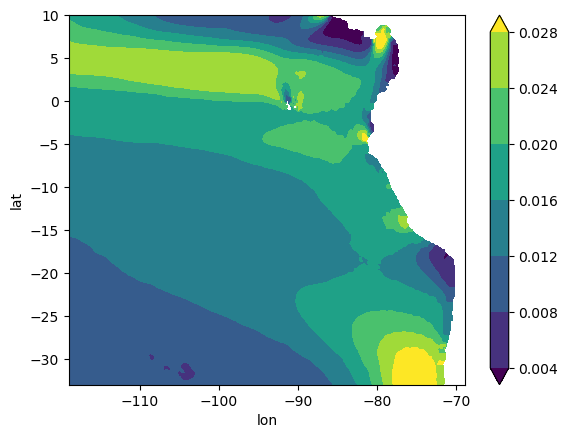

In [10]:
tau_alongshore.std('time').plot.contourf(robust=True)

In [11]:
rho_sw = 1025

BUI = tau_alongshore / (rho_sw * f)
# BUI.to_netcdf('BUI.nc')

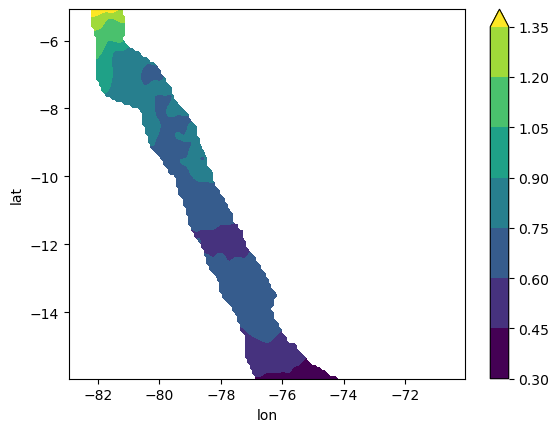

In [12]:
(BUI*inshore_mask).sel(lat=slice(-16,-5),lon=slice(-83,-70)).std('time').plot.contourf(robust=True)

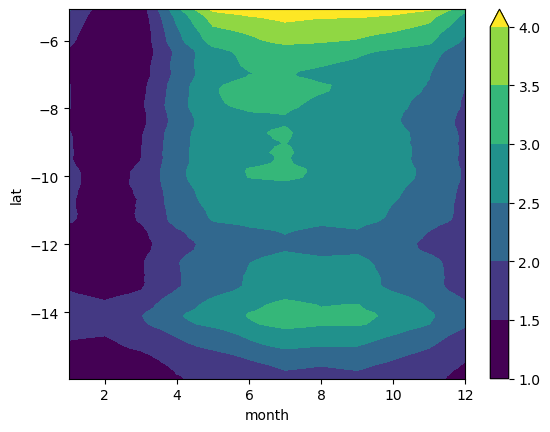

In [13]:
NBUI = (BUI*inshore_mask).sel(lat=slice(-16,-5),lon=slice(-83,-70))

seasonality(NBUI).mean(dim='lon').plot.contourf(x='month',robust=True)

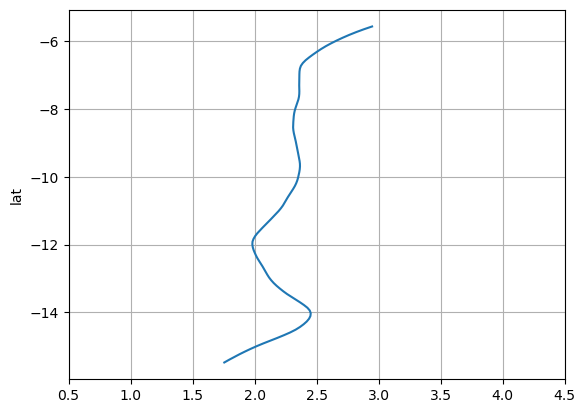

In [16]:
(NBUI.mean(dim=('lon','time')).rolling(lat=13,center=True).mean()).plot(y='lat',label='BUI')
plt.xlim([0.5 ,4.5])
plt.grid()

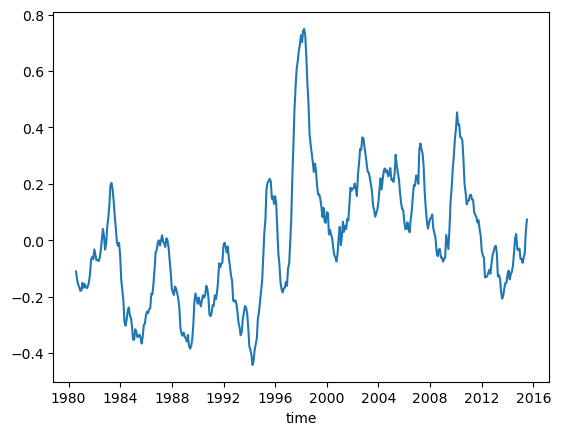

In [68]:
monthly_anomaly(NBUI).rolling(time=13,center=True).mean().plot()

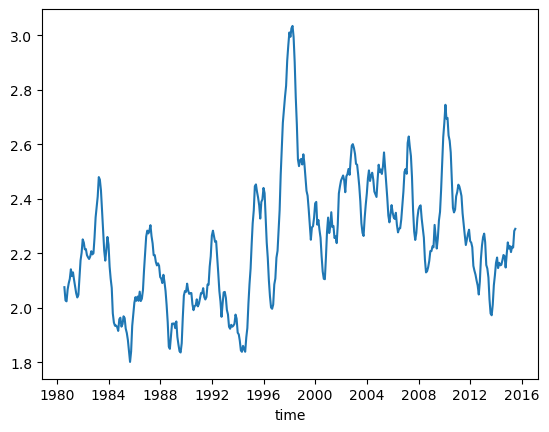

In [69]:
NBUI.mean(dim=('lat','lon')).rolling(time=13,center=True).mean().plot()